In [1]:
import pandas as pd
Input_Space = pd.read_excel('Input_Space.xlsx',engine='openpyxl')
#type(Input_Space)
del Input_Space['BLOC_1']
del Input_Space['BLOC_2']
Input_Space

,RM_1,RM_2,RM_3,RM_4,PR_temp,PR_speed
0,0.5,4.0,3.5,10,23,50
1,1.0,0.5,5.0,15,18,40
2,1.5,1.0,2.0,7,25,70
3,2.0,1.5,3.5,10,30,25
4,3.5,2.0,0.5,9,23,80
5,0.5,0.5,1.0,12,27,90
6,1.0,1.0,1.5,10,18,50
7,1.5,1.5,2.0,13,32,40
8,2.0,2.0,5.0,14,30,70
9,3.5,3.5,4.0,7,23,25


In [2]:
Output_Space = pd.read_excel('Output_Space.xlsx',engine='openpyxl')
Output_Space

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
0,128.0,25000,6.920819,67.480662,1,2,2,100.0,649.5
1,137.5,27625,11.792500,16.582639,1,1,3,25.0,546.0
2,55.0,39250,4.110698,54.859325,1,2,3,75.0,1009.0
3,120.5,48875,6.890253,99.770620,0,3,3,92.5,23.5
4,72.0,56500,6.259637,13.420144,0,1,5,85.0,1245.5
5,9.5,31625,9.440692,70.877713,1,3,2,35.0,1377.0
6,37.0,27250,6.500000,64.223469,0,2,3,47.5,737.5
7,74.5,45875,10.103749,50.865358,1,2,3,75.0,289.0
8,178.0,48500,10.756962,89.468562,1,3,4,95.0,929.0
9,188.5,55375,3.785819,98.781719,0,3,4,100.0,147.0


# Application de la normalisation avec “MinMaxScaler” dans le package #preprocessing.

In [3]:
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
# MIN MAX SCALING
minmax_scale = MinMaxScaler().fit(Output_Space[['Cost', 'Visco','Ph', 'Rheo','Stability', 'Texture','Senso1', 'Naturality','Microbio30days']])
df_minmax = minmax_scale.transform(Output_Space[['Cost', 'Visco','Ph', 'Rheo','Stability', 'Texture','Senso1', 'Naturality','Microbio30days']])
df_minmax=pd.DataFrame(df_minmax)
df_minmax.columns =["Cost","Visco" ,"Ph","Rheo","Stability", "Texture" ,"Senso1" ,"Naturality","Microbio30days"]
df_minmax

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
0,0.662011,0.000000,0.433882,0.626059,1.0,0.5,0.000000,1.000000,0.413338
1,0.715084,0.050481,1.000000,0.036624,1.0,0.0,0.333333,0.166667,0.344998
2,0.254190,0.274038,0.107329,0.479895,1.0,0.5,0.333333,0.722222,0.650710
3,0.620112,0.459135,0.430330,1.000000,0.0,1.0,0.333333,0.916667,0.000000
4,0.349162,0.605769,0.357049,0.000000,0.0,0.0,1.000000,0.833333,0.806867
5,0.000000,0.127404,0.726706,0.665400,1.0,1.0,0.000000,0.277778,0.893694
6,0.153631,0.043269,0.384980,0.588339,0.0,0.5,0.333333,0.416667,0.471443
7,0.363128,0.401442,0.803757,0.433642,1.0,0.5,0.333333,0.722222,0.175305
8,0.941341,0.451923,0.879664,0.880695,1.0,1.0,0.666667,0.944444,0.597887
9,1.000000,0.584135,0.069576,0.988548,0.0,1.0,0.666667,1.000000,0.081545


# Application de la standardisation avec “StandardScaler” dans le package #preprocessing.

In [4]:
import pandas as pd    
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
df_scaled = pd.DataFrame(ss.fit_transform(Output_Space),columns =Output_Space.columns)
df_scaled

,Cost,Visco,Ph,Rheo,Stability,Texture,Senso1,Naturality,Microbio30days
0,0.626685,-1.340738,-0.150404,0.105718,1.0,-0.346410,-1.441153,1.145618,-0.330863
1,0.805513,-1.165406,1.661278,-1.747360,1.0,-1.732051,-0.480384,-1.338855,-0.550906
2,-0.747473,-0.388932,-1.195432,-0.353795,1.0,-0.346410,-0.480384,0.317460,0.433444
3,0.485504,0.253954,-0.161771,1.281320,-1.0,1.039230,-0.480384,0.897171,-1.661755
4,-0.427463,0.763254,-0.396284,-1.862499,-1.0,-1.732051,1.441153,0.648723,0.936249
5,-1.603968,-0.898232,0.786687,0.229397,1.0,1.039230,-1.441153,-1.007592,1.215821
6,-1.086306,-1.190453,-0.306898,-0.012868,-1.0,-0.346410,-0.480384,-0.593513,-0.143773
7,-0.380403,0.053574,1.033265,-0.499206,1.0,-0.346410,-0.480384,0.317460,-1.097295
8,1.567888,0.228907,1.276182,0.906246,1.0,1.039230,0.480384,0.979986,0.263361
9,1.765541,0.688111,-1.316248,1.245317,-1.0,1.039230,0.480384,1.145618,-1.399191


# Random Forest model and SHAP for Cost prediction

In [5]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y1 = Output_Space.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y1, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y1) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values1 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y1_minmax =df_minmax.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y1_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y1_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values1_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y1_scaled =df_scaled.loc[:,'Cost'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y1_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y1_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values1_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

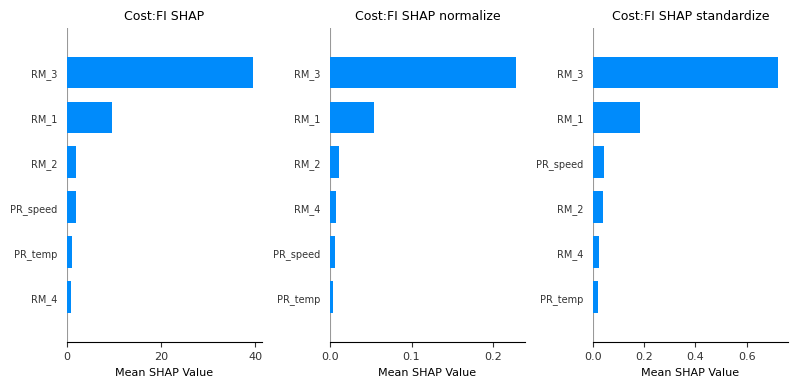

In [8]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Cost:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values1, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Cost:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values1_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Cost:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values1_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Cost.png')

# Random Forest model and SHAP for Visco prediction

In [9]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y2 = Output_Space.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y2, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y2) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values2 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y2_minmax =df_minmax.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y2_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y2_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values2_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y2_scaled =df_scaled.loc[:,'Visco'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y2_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y2_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values2_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

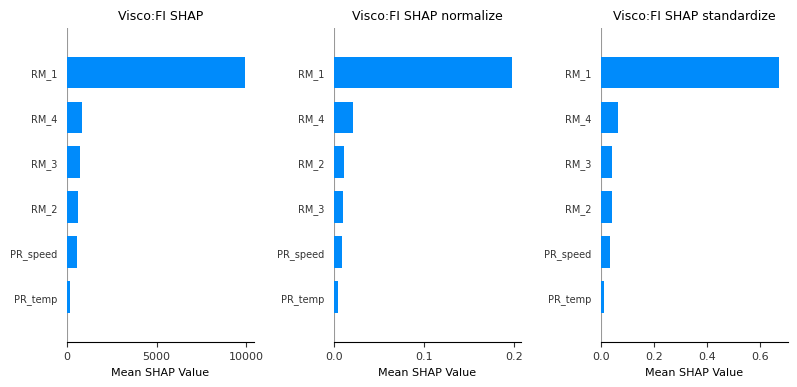

In [10]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Visco:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values2, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Visco:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values2_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Visco:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values2_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Visco.png')

# Random Forest model and SHAP for Ph prediction

In [11]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y3 = Output_Space.loc[:,'Ph'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y3, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y3) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values3 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y3_minmax =df_minmax.loc[:,'Ph'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y3_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y3_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values3_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y3_scaled =df_scaled.loc[:,'Ph'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y3_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y3_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values3_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

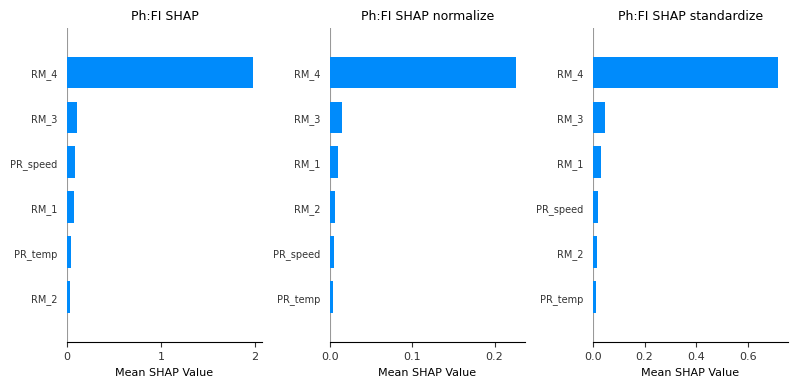

In [12]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Ph:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values3, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Ph:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values3_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Ph:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values3_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Ph.png')

# Random Forest model and SHAP for Rheo prediction

In [16]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y4 = Output_Space.loc[:,'Rheo'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y4, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y4) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values4 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y4_minmax =df_minmax.loc[:,'Rheo'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y4_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y4_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values4_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y4_scaled =df_scaled.loc[:,'Rheo'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y4_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y4_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values4_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

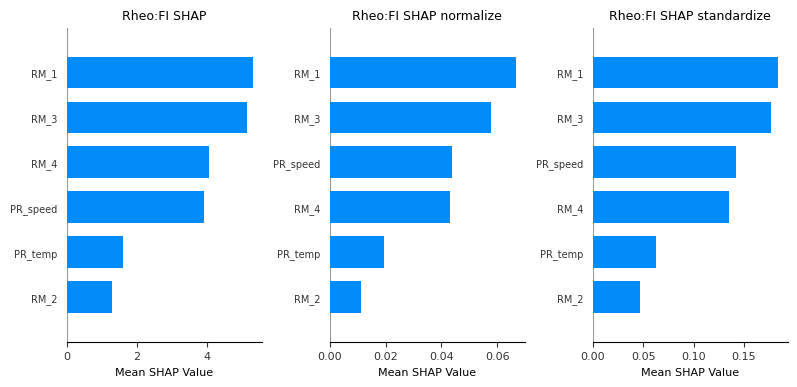

In [17]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Rheo:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values4, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Rheo:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values4_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Rheo:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values4_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Rheo.png')

# Random Forest model and SHAP for Stability prediction

In [18]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y5 = Output_Space.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y5, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y5) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y5_minmax =df_minmax.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y5_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y5_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y5_scaled =df_scaled.loc[:,'Stability'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y5_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y5_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values5_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

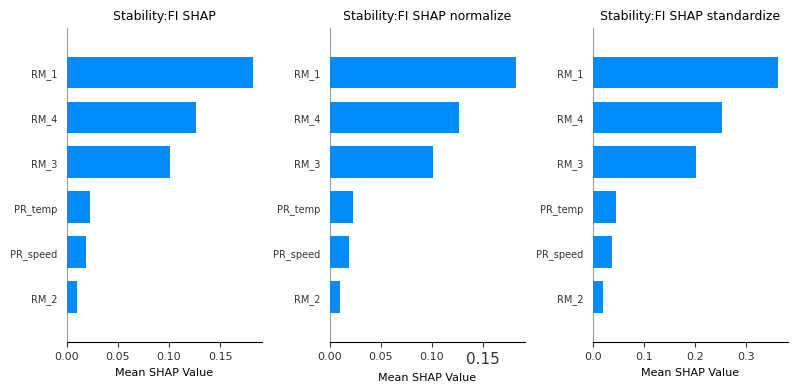

In [19]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Stability:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values5, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Stability:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values5_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Stability:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values5_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Stability.png')

# Random Forest model and SHAP for Texture prediction

In [22]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y6 = Output_Space.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y6, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y6) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y6_minmax =df_minmax.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y6_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y6_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y6_scaled =df_scaled.loc[:,'Texture'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y6_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y6_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values6_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

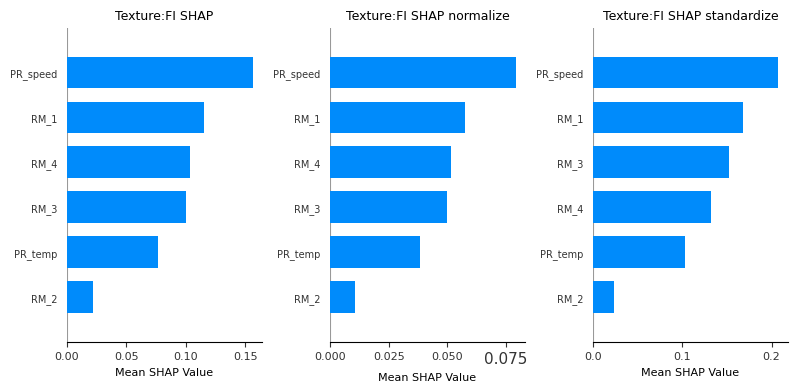

In [23]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Texture:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values6, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Texture:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values6_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Texture:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values6_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Texture.png')

# Random Forest model and SHAP for Senso1 prediction

In [24]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y7 = Output_Space.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y7, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y7) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y7_minmax =df_minmax.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y7_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y7_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y7_scaled =df_scaled.loc[:,'Senso1'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y7_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y7_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values7_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

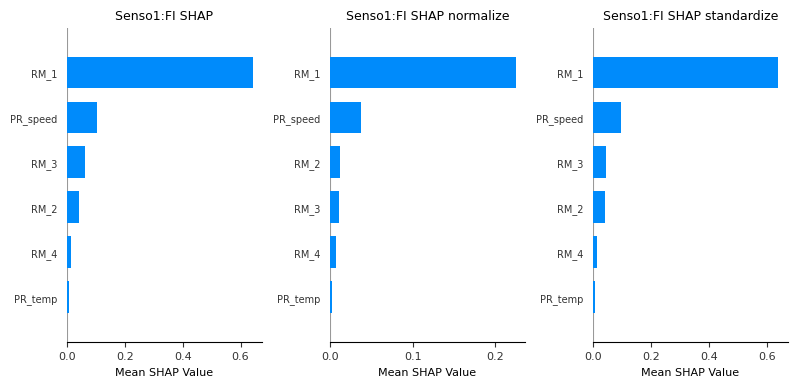

In [25]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Senso1:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values7, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Senso1:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values7_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Senso1:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values7_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Senso1.png')

# Random Forest model and SHAP for Naturality prediction

In [26]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y8 = Output_Space.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y8, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y8) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y8_minmax =df_minmax.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y8_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y8_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y8_scaled =df_scaled.loc[:,'Naturality'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y8_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y8_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values8_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

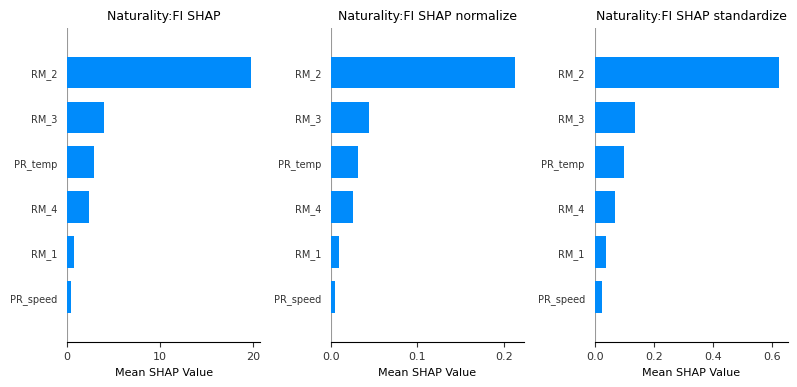

In [28]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Naturality:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values8, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Naturality:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values8_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Naturality:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values8_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Naturality.png')

# Random Forest model and SHAP for Microbio30days prediction

In [29]:
##### Random Forest model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
##################### Random Forest application
Y9 = Output_Space.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , Y9, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, Y9) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9 = shap.TreeExplainer(model).shap_values(X)
####################  Application de la normalisation avec “MinMaxScaler” dans le package preprocessing.
y9_minmax =df_minmax.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X ,y9_minmax, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y9_minmax) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9_minmax = shap.TreeExplainer(model).shap_values(X)
####################  Application de la standardisation avec “StandardScaler” dans le package preprocessing.
y9_scaled =df_scaled.loc[:,'Microbio30days'].astype(float)
X = Input_Space
model = RandomForestRegressor(n_estimators =100, random_state =0)
Score=cross_val_score(model, X , y9_scaled, cv=10, scoring=make_scorer(mean_squared_error))
mean_mse, std_mse = np.mean(Score), np.std(Score)
# fit the regressor with x and y data
model.fit(X, y9_scaled) 
##### SHAP explaination
import shap
##### SHAP explaination
shap_values9_scaled = shap.TreeExplainer(model).shap_values(X)

# Analyse Visuelle

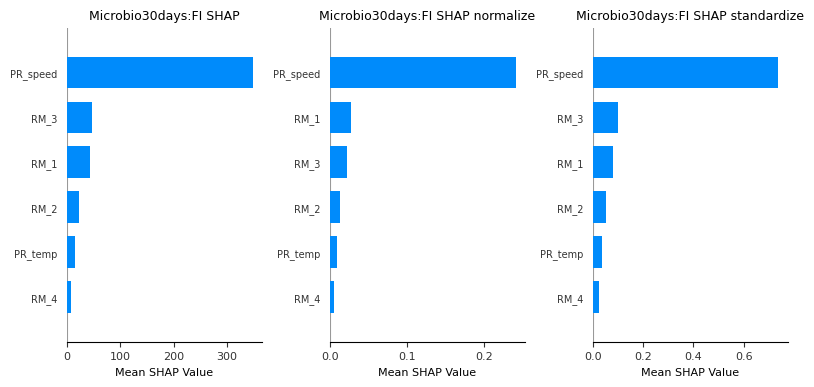

In [30]:
######################## feature importance SHAP
fig = plt.figure(figsize = (10, 10))
sub1 = fig.add_subplot(131) # instead of plt.subplot(2, 2, 1)
sub1.set_title('Microbio30days:FI SHAP',fontsize=9) # non OOP: plt.title('The function f')
#features = X.columns
shap.summary_plot(shap_values9, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
#plt.suptitle("Cost:features importances SHAP")
sub2 = fig.add_subplot(132)
sub2.set_title('Microbio30days:FI SHAP normalize',fontsize=9)
shap.summary_plot(shap_values9_minmax, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)
sub3 = fig.add_subplot(133)
sub3.set_title('Microbio30days:FI SHAP standardize',fontsize=9)
shap.summary_plot(shap_values9_scaled, X, plot_type="bar",show=0,sort=True)
plt.xticks(fontsize=8)
plt.yticks(fontsize=7,color ='0.2')
plt.xlabel('Mean SHAP Value',fontsize=8)

plt.subplots_adjust(left=0.1,
                    bottom=0.5, 
                    right=0.9, 
                    top=0.9, 
                    wspace=1, 
                    hspace=3)
plt.tight_layout(pad=0.8,h_pad=1)
#plt.show()
plt.savefig('latex/shap_scaling_Microbio30days.png')